# v3a: Confusion Matrix + t-SNE Misclassification Analysis

**1024-dim embeddings版** — DenseNet-121 GAP後の1024次元特徴でt-SNEを実行。
従来の7次元logits版より豊かな特徴空間を可視化する（Esteva et al. 2017, Cino et al. 2025 準拠）。

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from pathlib import Path
import seaborn as sns

# ── Config ─────────────────────────────────────────
NPZ_PATH = Path('../results/models/v3a_test_predictions.npz')
EMB_PATH = Path('../results/embeddings/v3a_test_embeddings.npz')
TS_PATH  = Path('../results/v4_TS/temperature_v3a.json')
PH_PATH  = Path('../results/v5_ph/posthoc_thresholds_v3a.json')
OUT_DIR  = Path('../results/tsne')
OUT_DIR.mkdir(parents=True, exist_ok=True)
Path('../results/embeddings').mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {
    'akiec': 'AKIEC\n(Actinic Ker.)',
    'bcc':   'BCC\n(Basal Cell Ca.)',
    'bkl':   'BKL\n(Benign Ker.)',
    'df':    'DF\n(Dermatofibroma)',
    'mel':   'MEL\n(Melanoma)',
    'nv':    'NV\n(Melanocytic Nevi)',
    'vasc':  'VASC\n(Vascular)',
}
MALIGNANT = {'akiec', 'bcc', 'mel'}
MALIGNANT_INDICES = [i for i, c in enumerate(CLASS_NAMES) if c in MALIGNANT]
BENIGN_INDICES    = [i for i, c in enumerate(CLASS_NAMES) if c not in MALIGNANT]

CLASS_COLORS = {
    'akiec': '#e11d48', 'bcc': '#dc2626', 'bkl': '#3b82f6',
    'df': '#06b6d4', 'mel': '#7f1d1d', 'nv': '#2563eb', 'vasc': '#8b5cf6',
}

## 0. Feature Extraction (1024-dim embeddings)

DenseNet-121 の GAP (Global Average Pooling) 後、classifier 直前の 1024次元特徴を抽出。
Esteva et al. (Nature, 2017) Figure 4 と同じ、最終隠れ層の表現を使う。

抽出済み npz が存在すればスキップ（GPU不要で再実行可能）。

In [2]:
# ── 1024-dim embedding extraction ──────────────────
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from glob import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import os

if EMB_PATH.exists():
    print(f'Embeddings already exist: {EMB_PATH} — skipping extraction')
else:
    print('Extracting 1024-dim embeddings from DenseNet-121...')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Data split (v3aと同一) ──
    data_dir = '../data'
    all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))
    imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
    df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
    df_original['cell_type_idx'] = df_original['dx'].map(dx_to_idx)

    df_undup = df_original.groupby('lesion_id').count()
    df_undup = df_undup[df_undup['image_id'] == 1].reset_index()
    unique_ids = set(df_undup['lesion_id'])
    df_undup_full = df_original[df_original['lesion_id'].isin(unique_ids)]

    _, df_valtest = train_test_split(
        df_undup_full, test_size=0.2, random_state=42,
        stratify=df_undup_full['cell_type_idx']
    )
    _, df_test = train_test_split(
        df_valtest, test_size=0.5, random_state=42,
        stratify=df_valtest['cell_type_idx']
    )
    df_test = df_test.reset_index(drop=True)
    print(f'  Test set: {len(df_test)} images')

    # ── Model ──
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(1024, 7)

    # Find .pth file
    pth_candidates = sorted(glob('../models/densenet_v3a_*.pth'))
    assert len(pth_candidates) > 0, 'No v3a .pth found in ../models/'
    pth_path = pth_candidates[-1]  # latest
    state = torch.load(pth_path, map_location='cpu', weights_only=True)
    model.load_state_dict(state)
    print(f'  Model loaded: {pth_path}')

    # Remove classifier → backbone outputs 1024-dim after GAP
    model.classifier = nn.Identity()
    model = model.to(device)
    model.eval()

    # ── Transform (eval only) ──
    NORM_MEAN = [0.7635, 0.5461, 0.5705]
    NORM_STD  = [0.1404, 0.1520, 0.1695]
    eval_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ])

    class SimpleDataset(Dataset):
        def __init__(self, df, transform):
            self.df = df
            self.transform = transform
        def __len__(self):
            return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['path']).convert('RGB')
            return self.transform(img), row['cell_type_idx']

    loader = DataLoader(SimpleDataset(df_test, eval_tf), batch_size=64,
                        shuffle=False, num_workers=4, pin_memory=True)

    # ── Extract ──
    all_emb, all_y = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            emb = model(imgs.to(device, non_blocking=True))
            all_emb.append(emb.cpu().numpy())
            all_y.append(labels.numpy())

    embeddings = np.concatenate(all_emb)
    y_true_emb = np.concatenate(all_y)
    print(f'  Embeddings: {embeddings.shape}')

    assert embeddings.shape[1] == 1024, (
        f'Unexpected embedding dim: {embeddings.shape[1]} (expected 1024). '
        f'strict=False may have silently dropped backbone weights.'
    )

    np.savez(EMB_PATH, embeddings=embeddings, y_true=y_true_emb)
    print(f'  Saved: {EMB_PATH}')

    del model
    torch.cuda.empty_cache()

Embeddings already exist: ../results/embeddings/v3a_test_embeddings.npz — skipping extraction


In [3]:
# ── Load data ──────────────────────────────────────
print(f'Loading: {NPZ_PATH}')
data = np.load(NPZ_PATH)
all_probs  = data['all_probs']   # raw softmax
all_logits = data['all_logits']  # raw logits
y_true     = data['y_true']

N = len(y_true)
y_pred = all_probs.argmax(axis=1)
print(f'  N={N}, classes={len(CLASS_NAMES)}')
print(f'  Accuracy (argmax): {(y_pred == y_true).mean():.4f}')

# ── Load TS + thresholds from JSON ─────────────────
with open(TS_PATH) as f:
    T = json.load(f)['temperature']
print(f'  Temperature: {T}')

with open(PH_PATH) as f:
    ph = json.load(f)

# Binary threshold (prefer binary_clinical, fallback binary_youden)
if 'binary_clinical' in ph:
    BINARY_THRESHOLD = ph['binary_clinical']['threshold']
elif 'binary_youden' in ph:
    BINARY_THRESHOLD = ph['binary_youden']['threshold']
else:
    raise KeyError('binary threshold not found in posthoc JSON')
print(f'  Binary threshold: {BINARY_THRESHOLD}')

# TS-calibrated probs for binary classification
import torch, torch.nn.functional as F
logits_ts = torch.tensor(all_logits / T, dtype=torch.float32)
all_probs_ts = F.softmax(logits_ts, dim=1).numpy()
del logits_ts

# ── Load 1024-dim embeddings ──────────────────────
emb_data = np.load(EMB_PATH)
embeddings = emb_data['embeddings']
print(f'  Embeddings: {embeddings.shape} (from {EMB_PATH.name})')

# ── Critical: verify predictions and embeddings are same samples in same order ──
y_true_emb = emb_data['y_true']
assert np.array_equal(y_true, y_true_emb), (
    f'FATAL: y_true mismatch between predictions ({NPZ_PATH.name}) '
    f'and embeddings ({EMB_PATH.name}). Files were generated from '
    f'different splits — all plots would be invalid.'
)
print(f'  ✓ y_true match verified ({len(y_true)} samples)')


Loading: ../results/models/v3a_test_predictions.npz
  N=552, classes=7
  Accuracy (argmax): 0.9076
  Temperature: 1.4477543830871582
  Binary threshold: 0.1439024806022644
  Embeddings: (552, 1024) (from v3a_test_embeddings.npz)
  ✓ y_true match verified (552 samples)


## 1. Confusion Matrix

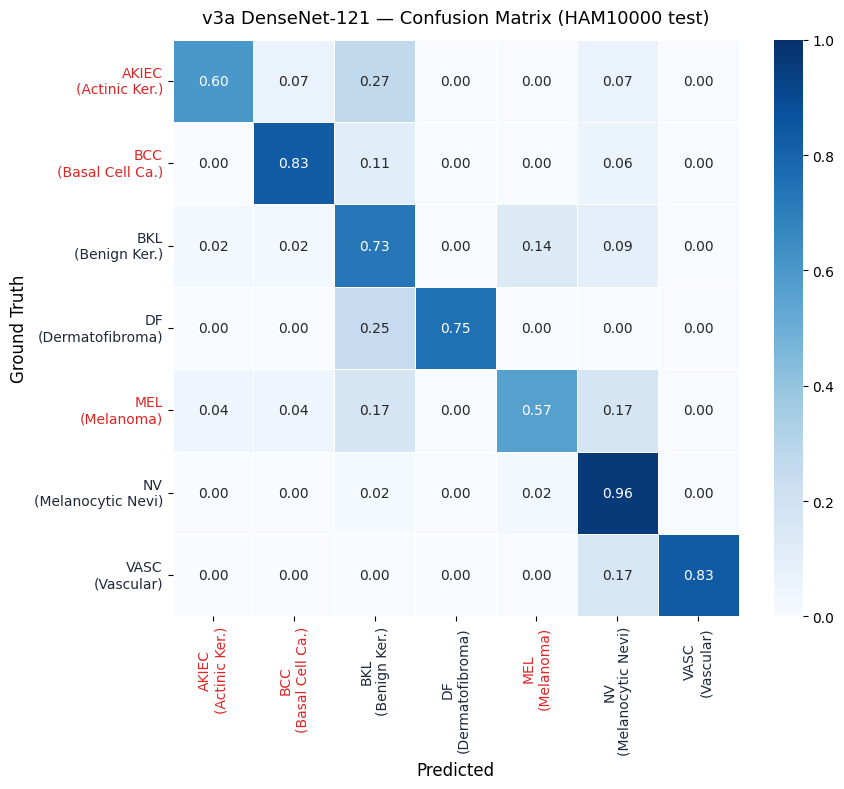


mel misclassified as:
  mel → akiec: 0.043
  mel → bcc: 0.043
  mel → bkl: 0.174
  mel → nv: 0.174


In [4]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[CLASS_LABELS[c] for c in CLASS_NAMES],
    yticklabels=[CLASS_LABELS[c] for c in CLASS_NAMES],
    ax=ax, vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Ground Truth', fontsize=12)
ax.set_title('v3a DenseNet-121 — Confusion Matrix (HAM10000 test)', fontsize=13, pad=12)

for i, cls in enumerate(CLASS_NAMES):
    color = '#dc2626' if cls in MALIGNANT else '#1e293b'
    ax.get_xticklabels()[i].set_color(color)
    ax.get_yticklabels()[i].set_color(color)

plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_confusion_matrix.png', dpi=150)
plt.show()

# mel row misclassification targets
mel_idx = CLASS_NAMES.index('mel')
print(f'\nmel misclassified as:')
for j, cls in enumerate(CLASS_NAMES):
    if j != mel_idx and cm[mel_idx, j] > 0.01:
        print(f'  mel → {cls}: {cm[mel_idx, j]:.3f}')

## 2. t-SNE (by class)

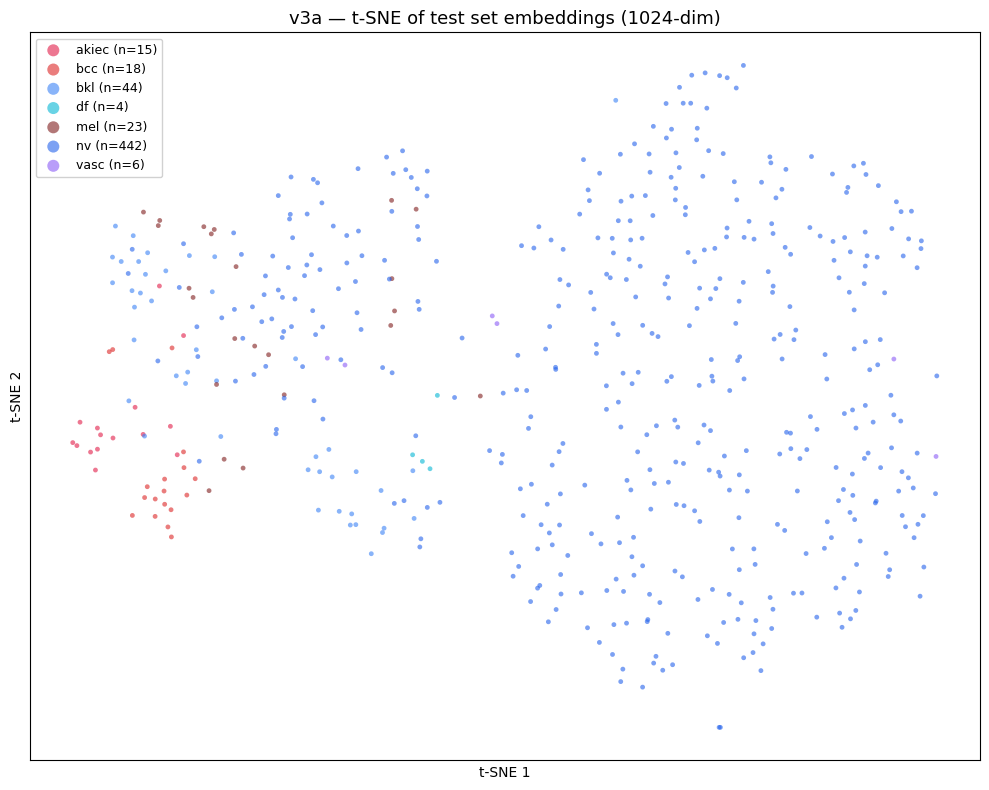

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embedding = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=CLASS_COLORS[cls], label=f'{cls} (n={mask.sum()})',
        s=12, alpha=0.6, edgecolors='none',
    )
ax.legend(fontsize=9, markerscale=2.5, loc='best', framealpha=0.9)
ax.set_title('v3a — t-SNE of test set embeddings (1024-dim)', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_tsne_class.png', dpi=150)
plt.show()

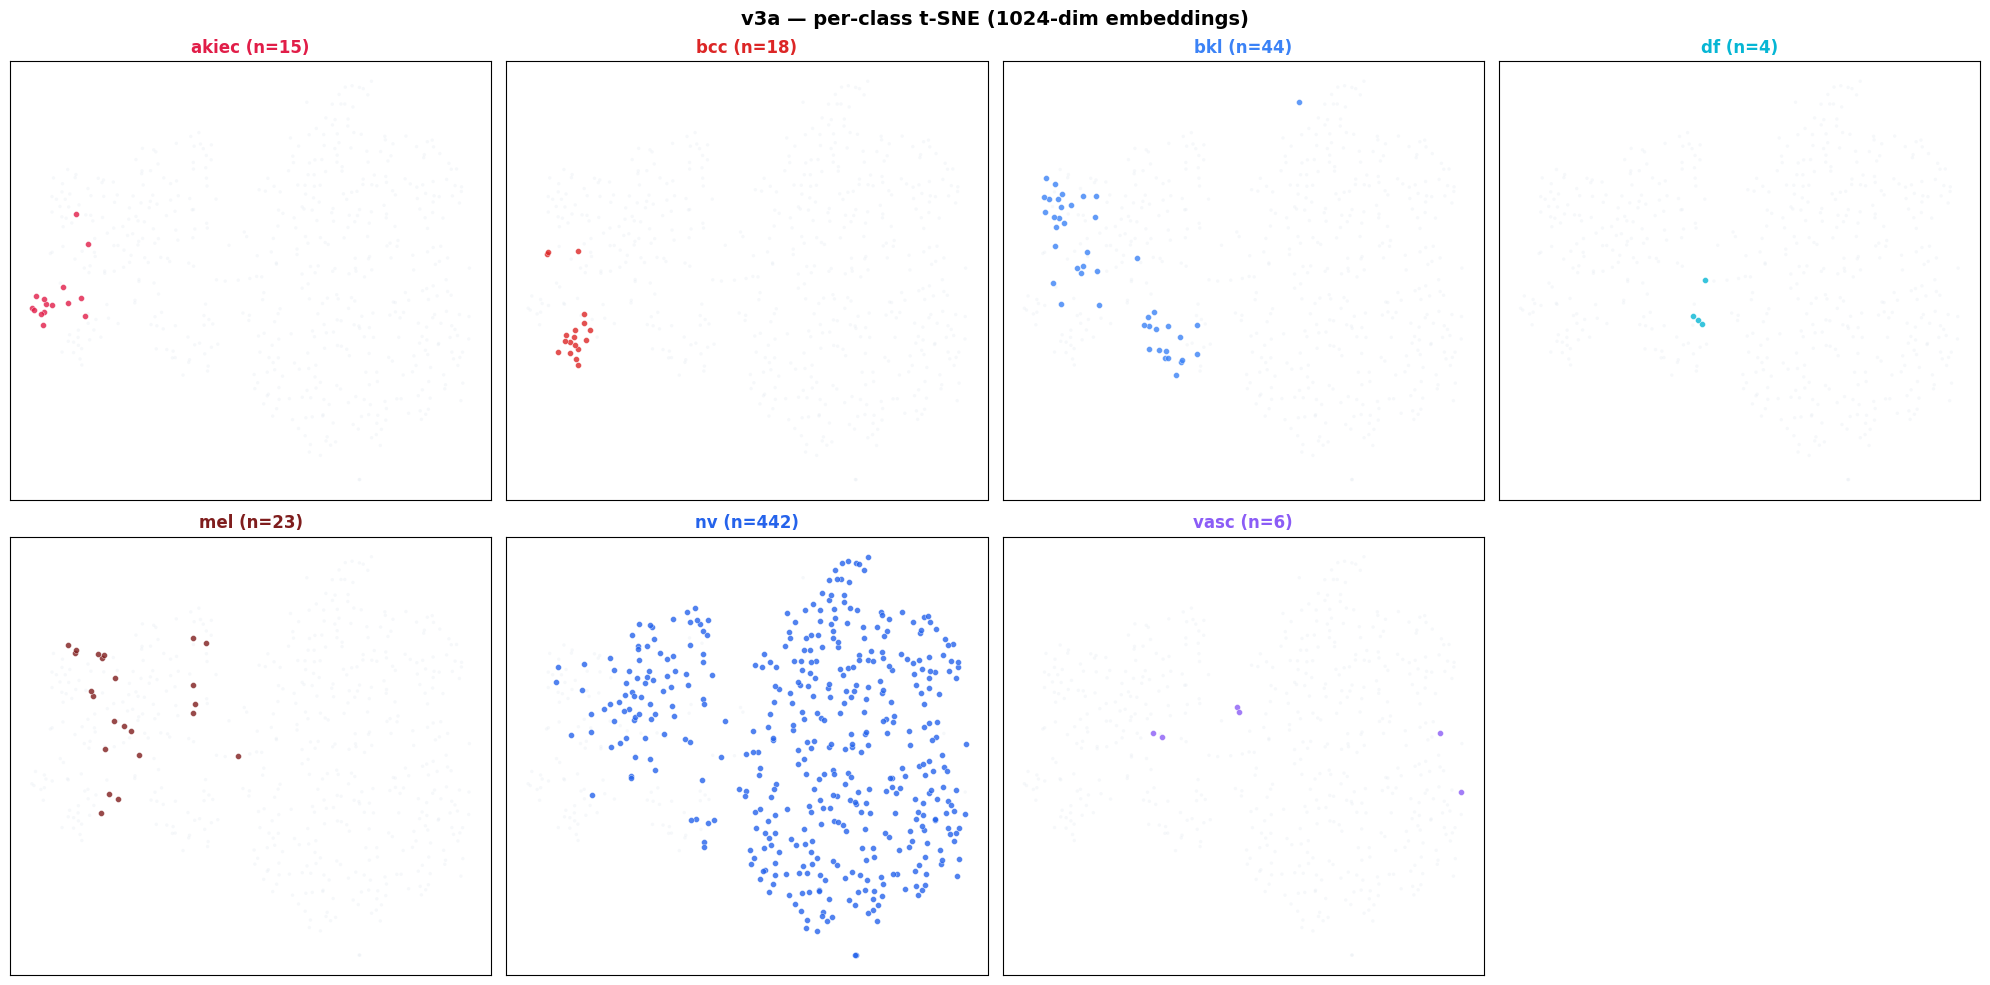

In [6]:
# Per-class t-SNE highlight
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    ax = axes[i]
    mask = y_true == i
    other = ~mask
    ax.scatter(embedding[other, 0], embedding[other, 1],
               c='#e2e8f0', s=6, alpha=0.3, edgecolors='none')
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=CLASS_COLORS[cls], s=18, alpha=0.8, edgecolors='white', linewidths=0.3)
    ax.set_title(f'{cls} (n={mask.sum()})', fontsize=12, fontweight='bold', color=CLASS_COLORS[cls])
    ax.set_xticks([]); ax.set_yticks([])

axes[7].set_visible(False)

plt.suptitle('v3a — per-class t-SNE (1024-dim embeddings)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_tsne_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. t-SNE (class + argmax misclassification highlight)

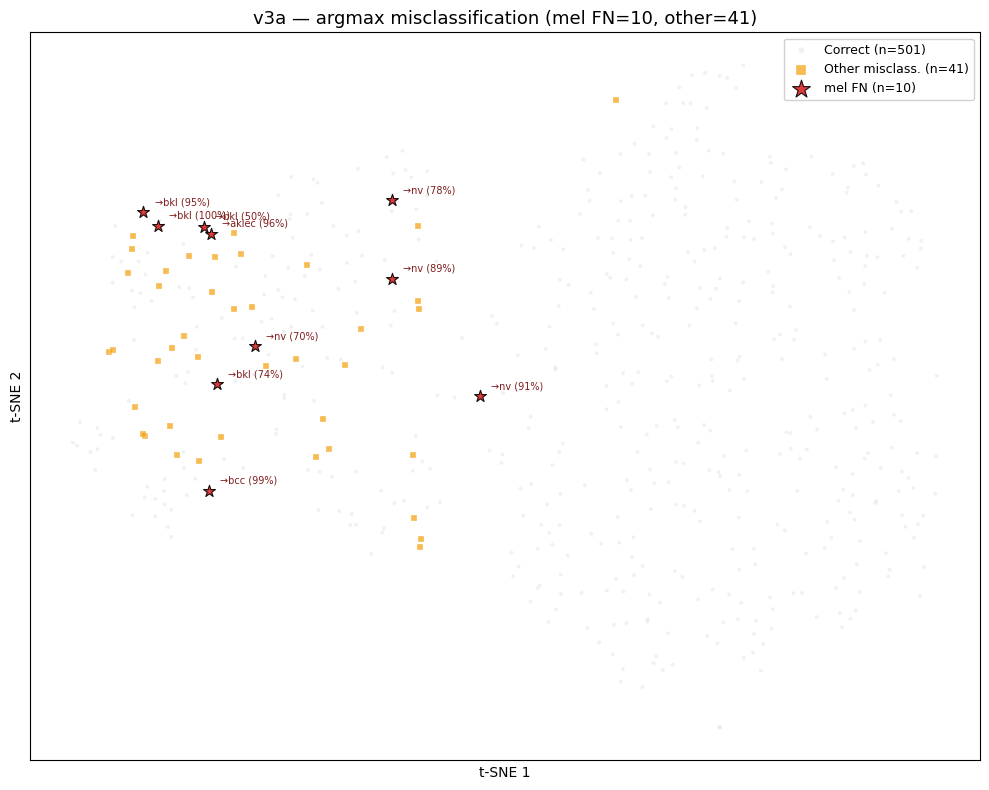

In [7]:
is_correct = y_pred == y_true
is_misclass = ~is_correct
is_mel_fn = (y_true == mel_idx) & is_misclass  # mel FN (critical)
is_other_misclass = is_misclass & ~is_mel_fn

fig, ax = plt.subplots(figsize=(10, 8))

# Correct: light gray
ax.scatter(
    embedding[is_correct, 0], embedding[is_correct, 1],
    c='#cbd5e1', s=8, alpha=0.3, edgecolors='none',
    label=f'Correct (n={is_correct.sum()})',
)

# Other misclassifications: orange square
ax.scatter(
    embedding[is_other_misclass, 0], embedding[is_other_misclass, 1],
    c='#f59e0b', s=25, alpha=0.7, edgecolors='white', linewidths=0.3,
    label=f'Other misclass. (n={is_other_misclass.sum()})', marker='s',
)

# mel FN: red star
ax.scatter(
    embedding[is_mel_fn, 0], embedding[is_mel_fn, 1],
    c='#dc2626', s=80, alpha=0.9, edgecolors='black', linewidths=0.8,
    label=f'mel FN (n={is_mel_fn.sum()})', marker='*', zorder=10,
)

# mel FN annotations
for idx in np.where(is_mel_fn)[0]:
    pred_cls = CLASS_NAMES[y_pred[idx]]
    conf = all_probs[idx, y_pred[idx]]
    ax.annotate(
        f'→{pred_cls} ({conf:.0%})',
        (embedding[idx, 0], embedding[idx, 1]),
        fontsize=7, color='#7f1d1d',
        textcoords='offset points', xytext=(8, 5),
        arrowprops=dict(arrowstyle='-', color='#7f1d1d', lw=0.5),
    )

ax.legend(fontsize=9, markerscale=1.5, loc='best', framealpha=0.9)
ax.set_title(f'v3a — argmax misclassification (mel FN={is_mel_fn.sum()}, other={is_other_misclass.sum()})', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_tsne_class_misclass.png', dpi=150)
plt.show()

## 4. t-SNE (malignant/benign binary)

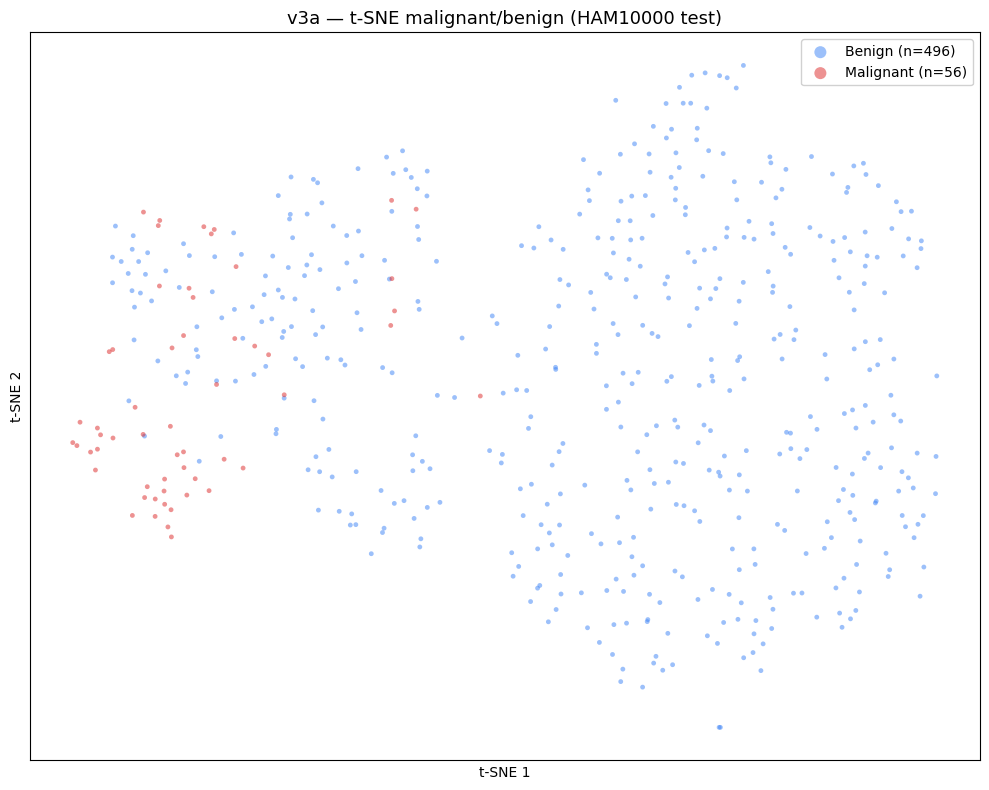

In [8]:
y_true_bin = np.isin(y_true, MALIGNANT_INDICES).astype(int)
n_mal = y_true_bin.sum()
n_ben = (1 - y_true_bin).sum()

fig, ax = plt.subplots(figsize=(10, 8))

# Benign: blue
ben_mask = y_true_bin == 0
ax.scatter(
    embedding[ben_mask, 0], embedding[ben_mask, 1],
    c='#3b82f6', s=12, alpha=0.5, edgecolors='none',
    label=f'Benign (n={n_ben})',
)

# Malignant: red
mal_mask = y_true_bin == 1
ax.scatter(
    embedding[mal_mask, 0], embedding[mal_mask, 1],
    c='#dc2626', s=12, alpha=0.5, edgecolors='none',
    label=f'Malignant (n={n_mal})',
)

ax.legend(fontsize=10, markerscale=2.5, loc='best', framealpha=0.9)
ax.set_title('v3a — t-SNE malignant/benign (HAM10000 test)', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_tsne_binary.png', dpi=150)
plt.show()

## 5. t-SNE (binary threshold-based misclassification)

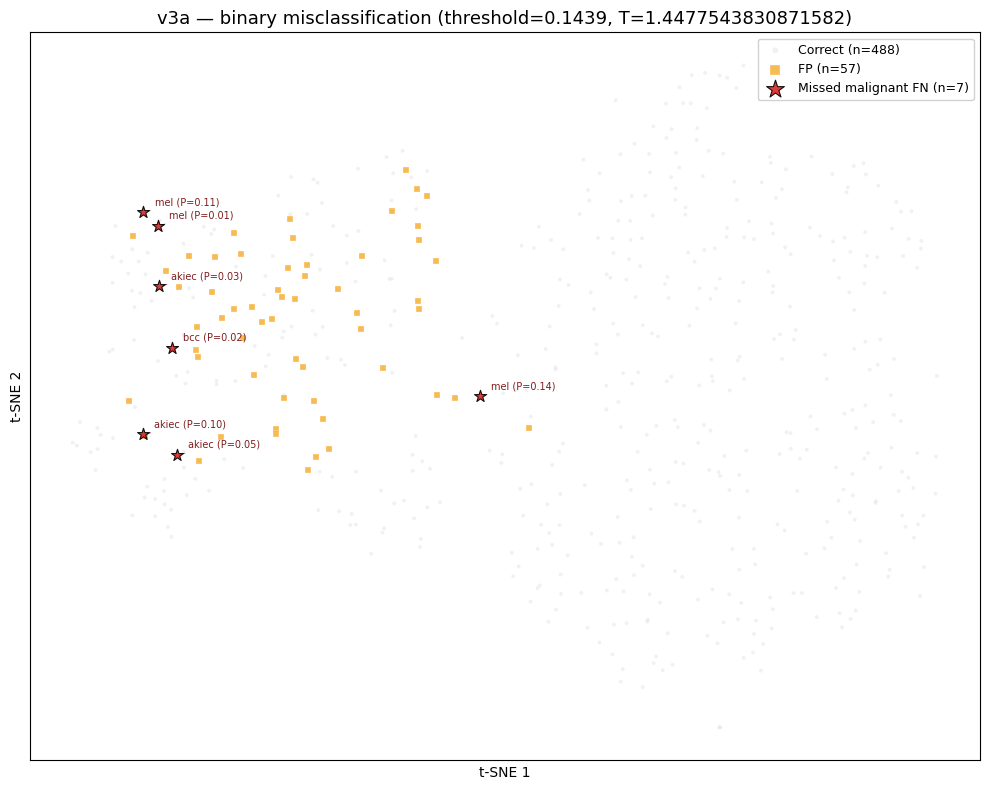

In [9]:
# Binary classification with TS-calibrated probs
p_mal = all_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)
y_pred_bin = (p_mal >= BINARY_THRESHOLD).astype(int)

is_correct_bin = y_pred_bin == y_true_bin
is_fn = (y_true_bin == 1) & (y_pred_bin == 0)  # missed malignant
is_fp = (y_true_bin == 0) & (y_pred_bin == 1)  # benign classified as malignant

fig, ax = plt.subplots(figsize=(10, 8))

# Correct: light gray
ax.scatter(
    embedding[is_correct_bin, 0], embedding[is_correct_bin, 1],
    c='#cbd5e1', s=8, alpha=0.3, edgecolors='none',
    label=f'Correct (n={is_correct_bin.sum()})',
)

# FP: orange square
ax.scatter(
    embedding[is_fp, 0], embedding[is_fp, 1],
    c='#f59e0b', s=25, alpha=0.7, edgecolors='white', linewidths=0.3,
    label=f'FP (n={is_fp.sum()})', marker='s',
)

# FN (missed malignant): red star
ax.scatter(
    embedding[is_fn, 0], embedding[is_fn, 1],
    c='#dc2626', s=80, alpha=0.9, edgecolors='black', linewidths=0.8,
    label=f'Missed malignant FN (n={is_fn.sum()})', marker='*', zorder=10,
)

# FN annotations (true class + P(mal))
for idx in np.where(is_fn)[0]:
    true_cls = CLASS_NAMES[y_true[idx]]
    ax.annotate(
        f'{true_cls} (P={p_mal[idx]:.2f})',
        (embedding[idx, 0], embedding[idx, 1]),
        fontsize=7, color='#7f1d1d',
        textcoords='offset points', xytext=(8, 5),
        arrowprops=dict(arrowstyle='-', color='#7f1d1d', lw=0.5),
    )

ax.legend(fontsize=9, markerscale=1.5, loc='best', framealpha=0.9)
ax.set_title(f'v3a — binary misclassification (threshold={BINARY_THRESHOLD:.4f}, T={T})', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v3a_tsne_binary_misclass.png', dpi=150)
plt.show()

## Summary

In [10]:
print(f'=== v3a t-SNE Summary ===')
print(f'  test N: {N}')
print(f'  argmax accuracy: {(y_pred == y_true).mean():.4f}')
print(f'  argmax misclass.: {is_misclass.sum()} ({is_misclass.mean():.1%})')
print(f'    of which mel FN: {is_mel_fn.sum()}')
print()
print(f'  Binary (T={T}, threshold={BINARY_THRESHOLD:.4f}):')
print(f'    FN (missed malignant): {is_fn.sum()} / {n_mal} ({is_fn.sum()/max(n_mal,1):.1%})')
print(f'    FP: {is_fp.sum()} / {n_ben}')
print()
print(f'  mel FN (argmax) predicted as:')
for idx in np.where(is_mel_fn)[0]:
    pred_cls = CLASS_NAMES[y_pred[idx]]
    conf = all_probs[idx, y_pred[idx]]
    print(f'    → {pred_cls} (conf={conf:.3f})')
print()
print(f'  Binary FN breakdown (by true class):')
for idx in np.where(is_fn)[0]:
    true_cls = CLASS_NAMES[y_true[idx]]
    print(f'    {true_cls} (P(mal)={p_mal[idx]:.3f})')
print()
print(f'Output: {OUT_DIR}/')
for f in sorted(OUT_DIR.glob('v3a_*')):
    print(f'  {f.name}')

=== v3a t-SNE Summary ===
  test N: 552
  argmax accuracy: 0.9076
  argmax misclass.: 51 (9.2%)
    of which mel FN: 10

  Binary (T=1.4477543830871582, threshold=0.1439):
    FN (missed malignant): 7 / 56 (12.5%)
    FP: 57 / 496

  mel FN (argmax) predicted as:
    → bkl (conf=0.997)
    → akiec (conf=0.956)
    → nv (conf=0.782)
    → bcc (conf=0.989)
    → nv (conf=0.889)
    → nv (conf=0.696)
    → bkl (conf=0.501)
    → bkl (conf=0.946)
    → bkl (conf=0.738)
    → nv (conf=0.913)

  Binary FN breakdown (by true class):
    mel (P(mal)=0.011)
    bcc (P(mal)=0.018)
    mel (P(mal)=0.108)
    akiec (P(mal)=0.098)
    akiec (P(mal)=0.052)
    akiec (P(mal)=0.032)
    mel (P(mal)=0.136)

Output: ../results/tsne/
  v3a_confusion_matrix.png
  v3a_tsne_binary.png
  v3a_tsne_binary_misclass.png
  v3a_tsne_class.png
  v3a_tsne_class_misclass.png
  v3a_tsne_perclass.png
  v3a_tsne_report.pdf


## Export to PDF

In [11]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

PAGES = [
    ('v3a_confusion_matrix.png',     'Confusion Matrix (7-class, normalized)'),
    ('v3a_tsne_class.png',           't-SNE — class distribution'),
    ('v3a_tsne_perclass.png',        't-SNE — per-class highlight'),
    ('v3a_tsne_class_misclass.png',  't-SNE — argmax misclassification (mel FN highlighted)'),
    ('v3a_tsne_binary.png',          't-SNE — malignant / benign binary'),
    ('v3a_tsne_binary_misclass.png', 't-SNE — binary threshold misclassification (FN / FP)'),
]

pdf_path = OUT_DIR / 'v3a_tsne_report.pdf'
with PdfPages(pdf_path) as pdf:
    # Title page
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('off')
    ax.text(0.5, 0.55, 'DermLens v3a — DenseNet-121 / HAM10000 test',
            ha='center', va='center', fontsize=22, fontweight='bold')
    ax.text(0.5, 0.42, 'Confusion Matrix + t-SNE Misclassification Analysis',
            ha='center', va='center', fontsize=14, color='#475569')
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    for fname, subtitle in PAGES:
        img = mpimg.imread(str(OUT_DIR / fname))
        fig, ax = plt.subplots(figsize=(11.69, 8.27))
        fig.text(0.5, 0.96, subtitle, ha='center', va='top',
                 fontsize=11, color='#475569', style='italic')
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.94])
        pdf.savefig(fig, dpi=150)
        plt.close(fig)

print(f'PDF saved: {pdf_path} ({len(PAGES)+1} pages)')

PDF saved: ../results/tsne/v3a_tsne_report.pdf (7 pages)
